# **Project work: E. Coli Colony Segmentation**

<div style="color:#777777;margin-top: -15px;">
<b>Course</b>: MSLS / CO4 |
<b>Version</b>: v1.3 <br><br>
<!-- 10.04.2025, v1.2: Fully refactored -->
<!-- 17.04.2026, v1.3: Introduced word count limits -->
</div>


**Students**: Livia Vinzens, Cyrille Niklaus

**Email**: vinzeliv@students.zhaw.ch, niklacyr@students.zhaw.ch

**University**: ZHAW

**Semester**: 2nd Semester

**Date**: 29.05.2026

**Repository**: https://github.com/liviavinz/CO4_image_project


<br>

## **Abstract**

*This project develops a classical image segmentation pipeline for E. coli colony detection on self-made petri dishes. Our goal was to be able to identfy and count colonies in an image. We created our own dataset, scanning agar plates colored with food-grade dyes to distinguish antibiotic types: red for Kanamycin, green for Carbenicillin, and white for non-antibiotic added. We extracted snippets from full plates and applied a series of preprocessing steps: quantization to reduce color noise, morphological operations to remove dust and scratches and denoising to smooth the image. We then performed k-means clustering for segmentation, followed by connected component analysis to extract colony information (masks and counts of individual colonies). To validate our results, we manually segmented regions in GIMP to create ground-truth masks and compared them against our automated approach. Additionally, we explored thresholding techniques to separate touching colonies.*



<br><br>

----

## **Table of contents**
<!-- Unfortunately, the following does not always work correctly -->
* [1. Dataset](#sec_dataset)  
* [2. Preprocessing](#sec_preprocessing)  
* [3. Manual segmentation](#sec_manual_segmentation)  
* [4. Automated segmentation](#sec_automated_segmentation)  
* [5. Evaluation](#sec_evaluation)  
* [6. Discussion](#sec_discussion)  


---

## **Prerequisites / Setup**

* We used the same environment which was provided for the Jupyter Notebook exercises in CO4.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2 as cv
import PIL
from PIL import Image
import os
import re

# Jupyter / IPython configuration:
# Automatically reload modules when modified
%load_ext autoreload
%autoreload 2

# Enable vectorized output (for nicer plots)
%config InlineBackend.figure_formats = ["svg"]

# Inline backend configuration
%matplotlib inline

import sys
sys.path.insert(0, "../")
import tools


---


<a id='sec_dataset'></a>

## **Dataset**

Cyrille is working as a Lab Technician at the Institute of Medical Virology (IMV). We were allowed to use the laboratory to create petri dishes displaying *E. Coli* colonies. Petri dishes are bacterial culture plates, containing agarose (a polysaccharide with a gel like consistancy) supplemented with nutrients for the bacterias to grow. They are used for various experiments. An example would be environmental control where one wants to know the amount of microbial contamination in clean rooms for pharmaceutical production. Or testing transformation efficiency of competent bacteria which is a task we perform at the IMV. Both examples provided require to count the bacterial colonies seen on a petri dish.

For this project work we used three different petri dishes, each with different color dyes which are used in the lab to distinguish between antibiotics added to the agarose: red for kanamycin, green for carbenicillin and white as control with no antibiotic added. Antibiotic selection ensures that only bacteria carrying the corresponding resistance gene survive, thereby increasing the likelihood of obtaining the correct genetic construct. From a full scan of each petri dish, we extracted 4 snippets of size 500x500x3. We repeated this process for each petri dish, giving us a total of 12 images, 4 per color. We deliberately selected 2 out of 12 images with touching colonies to explore techniques which might be able to help separate them.


---

<a id='sec_preprocessing'></a>

## **Preprocessing**

**Overview**
1. **Cropping** petri dish out of scan
2. **Color quantization** to reduce color variation
3. **Cropping** snippets for dataset creation (12 images)
4. **Morphological operations** to remove dust and scratches
5. **Denoising** for smoothing


### **Cropping input image to obtain single petri dishes**
* The input image is a scan obtained by an old Epson scanner using the highest possible resolution in combination with a color restoration function. Dimensions: 13655x9816x3.
* The individual petri dishes are then cropped out of the input image.
    * We added those to the submission folder as the original scan was too large to submit.
* An image displaying a single petri dish has the dimensions 4150x4150x3.
* The images of the individual petri dish are combined to a list for further processing.

*Note*: Even though the green petri dish looks blue in the image, in real-life they are more greenish. The dye used is as well green. Therefor we reference those accordingly.

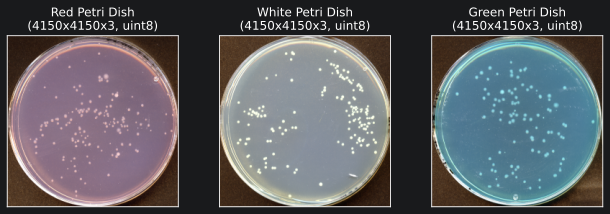

In [2]:
# # When using the original full scan image
# # Read test image
# multi_plate = cv.imread("multi_plate.tif", cv.IMREAD_COLOR)
# print("Shape of the input image", multi_plate.shape)
#
# # Change BGR to RGB representation
# multi_plate = cv.cvtColor(multi_plate, cv.COLOR_BGR2RGB)
#
# # Crop the petri dish and combine to list
# multi_crop_red = multi_plate[700:4850, 1000:5150].copy()
# multi_crop_white = multi_plate[4900:9050, 1000:5150].copy()
# multi_crop_green = multi_plate[9100:13250, 1200:5350].copy()

# When using already cropped images
file_path = "data_to_submit"
multi_crop_red = np.array(Image.open(os.path.join(file_path, "Red_Petri_Dish.png")), dtype=np.uint8)
multi_crop_white = np.array(Image.open(os.path.join(file_path, "White_Petri_Dish.png")), dtype=np.uint8)
multi_crop_green = np.array(Image.open(os.path.join(file_path, "Green_Petri_Dish.png")), dtype=np.uint8)


mult_plates = [multi_crop_red, multi_crop_white, multi_crop_green]
mult_titles = ["Red Petri Dish", "White Petri Dish", "Green Petri Dish"]

# Show our test images
tools.show_image_chain(mult_plates, titles = mult_titles)

### **Color Quantization**
* The images of individual petri dishes are quantized to cluster similar colors.
* Our assumption was, that quantization would group similar intensity values together, creating more uniform color intensity within colonies.


In [3]:
def quantize(image, nbits):
    """
    Function obtained from msls-co4-ss26 notebook.
    Quantize an image to a lower number of bits. The image must be
    in uint8 format. The number of bits must be between 1 and 8.
    The function works for an arbitrary number of channels.
    """
    assert image.dtype == np.uint8, "Image must be uint8"
    assert nbits > 0 and nbits <= 8, "Invalid number of bits"

    # Create equally sized bins for the 256 levels (per channel).
    bins = np.arange(0, 256+1, 256 // 2**nbits)
    ret = np.digitize(image, bins) - 1
    # ret -> array of bin indices, with the reduced number of levels.
    # Image still in uint8 format -> need to multiply the bin indices with the bin width.
    ret *= (256 // 2**nbits)
    return ret.astype(np.uint8)

def to_4_bit(image_list):
    """
    Sub-function which uses quantize() to convert to 4-bit.
    :param: image_list
    :return: 4-bit-image_list
    """
    to_4_bit_list = []
    for i in image_list:
        img_4_bit = quantize(i, 4)
        to_4_bit_list.append(img_4_bit)
    return to_4_bit_list

def to_6_bit(image_list):
    """
    Sub-function which uses quantize() to convert to 6-bit.
    :param: image_list
    :return: 6-bit-image_list
    """
    to_6_bit_list = []
    for i in image_list:
        img_6_bit = quantize(i, 6)
        to_6_bit_list.append(img_6_bit)
    return to_6_bit_list

imgs_4_bit = to_4_bit(mult_plates)
imgs_6_bit = to_6_bit(mult_plates)

### **Histogram Visualizations**
* The green petri dish acts as our example.
* Intensity values (pixel brightness) were visualized across the RGB color channels.
* Three versions (original, 6-bit, and 4-bit) were compared side by side.
* Histograms revealed how intensity bins are formed, with the 4-bit version showing distinct peaks in the color channels.
* Testing all three versions in the downstream process showed that 4-bit inputs performed best. When using the original or 6-bit version, our automated segmentation had difficulties separating close colonies (not even touching). Leading to the decision to proceed with 4-bit.

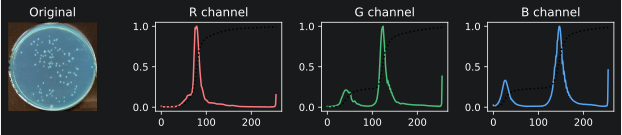

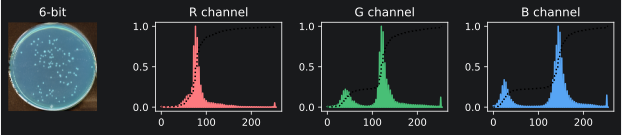

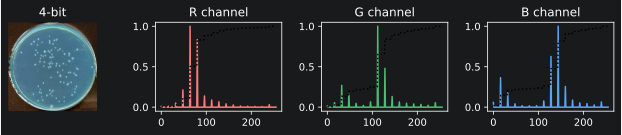

In [4]:
def visualize_histogram(image, title="Histogram"):
    """
    Function obtained from msls-co4-ss26 notebook.
    :param image: List of images
    :param title: Of the respective set of images provided
    :return: plot displaying input image and all 3 RBG channels with respective intensity distribution.
    """
    def visualize_channel(img, title, ax, color):
        hist, bins = np.histogram(img.flatten(), bins=256, range=[0,256], density=True)
        cdf = hist.cumsum()
        hist /= hist.max()
        ax.plot(hist, label="Histogram (normalized)", color=color)
        ax.plot(cdf, label="CDF", color="k", linestyle=":")
        if False:
            ax.set_xlabel("Pixel value")
            ax.legend()
        ax.set_title(title)

    """Visualize the histogram of an image."""
    if image.ndim == 1:
        return visualize_channel(image, title, plt.gca())
    else:
        nchannels = image.shape[-1]
        fig, axes = plt.subplots(1, nchannels+1, figsize=(9, 2))
        axes[0].imshow(image, cmap="gray" if nchannels == 1 else None)
        axes[0].axis("off")
        axes[0].set_title(title)
        axes[0].set_anchor("N")
        titles = ["R channel", "G channel", "B channel"]
        for i in range(image.shape[-1]):
            visualize_channel(image[..., i],
                              title=titles[i],
                              ax=axes[i+1], color=tools.PALETTE_RGB[i])
    #fig.suptitle(title)
    plt.tight_layout()

visualize_histogram(multi_crop_green, title="Original")
visualize_histogram(imgs_6_bit[2], title="6-bit")
visualize_histogram(imgs_4_bit[2], title="4-bit")

### **Manual snipped selection for dataset creation**
* Initially, we tried to perform the segmentation task on the whole plate. Unfortunately, we were not successfull to clearly separate the petri dish edges from the colonies. The leftovers of the edge lead to patches wrongly assinged as colonies. After a while of try and error we decided to continue with snippets of the whole plate.
* We cropped individual 500x500x3 images out of the single petri dish images for dataset creation.
* Images contain mostly separated bacterial colonies.
* Some contain colonies which are not separated to experiment with some techniques during later processing stages (*white_2* and *white_4*).

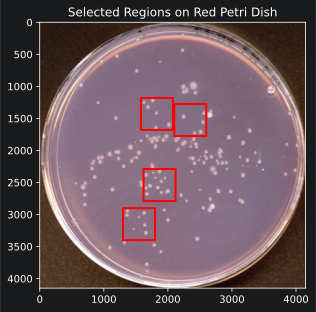

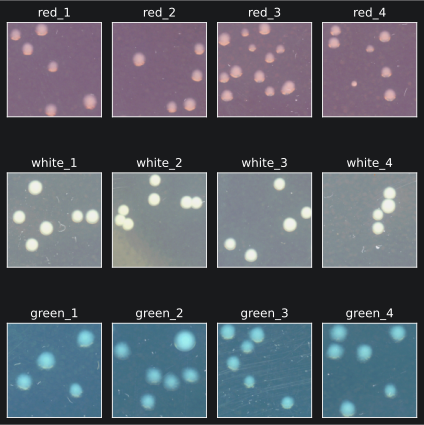

In [5]:
# Red agar petri dish
red_4_bit = imgs_4_bit[0]
red_1 = red_4_bit[1180:1680, 1580:2080].copy()
red_2 = red_4_bit[1275:1775, 2100:2600].copy()
red_3 = red_4_bit[2290:2790, 1620:2120].copy()
red_4 = red_4_bit[2900:3400, 1300:1800].copy()
imgs_red = [red_1, red_2, red_3, red_4]

# White agar petri dish
white_4_bit = imgs_4_bit[1]
white_1 = white_4_bit[2000:2500, 1400:1900].copy()
white_2 = white_4_bit[3050:3550, 900:1400].copy()
white_3 = white_4_bit[2200:2700, 2812:3312].copy()
white_4 = white_4_bit[1150:1650, 2200:2700].copy()
imgs_white = [white_1, white_2, white_3, white_4]

# Green agar petri dish
green_4_bit = imgs_4_bit[2]
green_1 = green_4_bit[700:1200, 1000:1500].copy()
green_2 = green_4_bit[1270:1770, 1325:1825].copy()
green_3 = green_4_bit[3120:3620, 1880:2380].copy()
green_4 = green_4_bit[1875:2375, 2180:2680].copy()
imgs_green = [green_1, green_2, green_3, green_4]

# Combine all 12 snippets to one list of images to create the dataset
imgs_all_color = [red_1, red_2, red_3, red_4, white_1, white_2, white_3, white_4, green_1, green_2, green_3, green_4]
titles_all_color = ["red_1", "red_2", "red_3", "red_4", "white_1", "white_2", "white_3", "white_4", "green_1", "green_2", "green_3", "green_4"]

# Showcase of the snippets obtained from the red petri dish
plt.imshow(multi_crop_red)
rect1 = patches.Rectangle((1580, 1180), 500, 500, linewidth=2, edgecolor='r', facecolor='none')
rect2 = patches.Rectangle((2100, 1275), 500, 500, linewidth=2, edgecolor='r', facecolor='none')
rect3 = patches.Rectangle((1620, 2290), 500, 500, linewidth=2, edgecolor='r', facecolor='none')
rect4 = patches.Rectangle((1300, 2900), 500, 500, linewidth=2, edgecolor='r', facecolor='none')
plt.gca().add_patch(rect1)
plt.gca().add_patch(rect2)
plt.gca().add_patch(rect3)
plt.gca().add_patch(rect4)
plt.title("Selected Regions on Red Petri Dish")
plt.show()

# Displaying all images in dataset
tools.show_image_grid(imgs_all_color, suppress_info=True, ncols=4, figsize=(6, 7), titles=titles_all_color)

### **Denoising**
We tried to illustrate how we experienced the denoising part. It did not work out in the first try as you will see.
* Scratches and dust particles are part of the images. With denosing, we try to get rid of them.
* We tried several methods (*Averaging, Gaussian Blur, Median Blur, Bilateral Filtering, Non-Local Denoising*), although none was able to perfectly satisfy on its own. Therefore, we proceeded with a combination of two methods.
* Below we have an example image of the green set. After applying the Non-Local (NL) Means denoising, we got a more uniform background without scratches, while the dust particles remained visible.
* Using subsequently a median blur technique, we were able to remove most of the dust particles, while keeping our bacterial colonies.

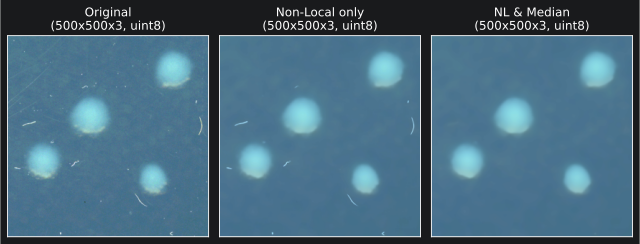

In [6]:
def blur(img):
    """
    Applies a combination of denoising techniques. Non-local Means Denoising followed by a median blurring.
    :param img: noisy image containing scratches and dust
    :return: denoised img
    """
    img_blur = cv.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)
    img_blur = cv.medianBlur(img_blur,9)
    return img_blur

green_NL = cv.fastNlMeansDenoisingColored(imgs_green[0], None,10,10,7,21)
green_combination = cv.medianBlur(green_NL,9)

blur_process = [imgs_green[0], green_NL, green_combination]

tools.show_image_chain(blur_process, titles = ["Original", "Non-Local only", "NL & Median"])


### **Denoising images in a batch**

In [7]:
# Create a list of all images where blur() was applied
imgs_all_blurred = [blur(i) for i in imgs_all_color]

### **Leftover Dust Particles**
* In the example below, we show that our denoising combination removed most of the noise.
* Unfortunately, some artifacts remained.
    * A larger dust particle was still present in *white_4*, which led to the wrong interpretation that it might be a colony.

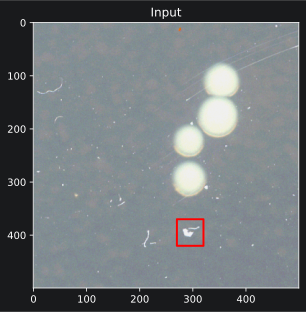

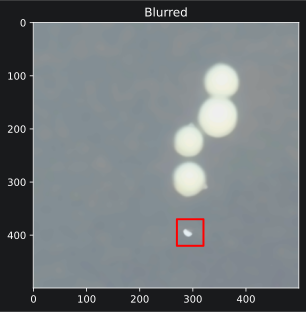

In [8]:
# Display the full image
plt.imshow(imgs_all_color[7])

# Create a rectangle patch
rect = patches.Rectangle((270, 370), 50, 50, linewidth=2, edgecolor='r', facecolor='none')

# Add the rectangle to the plot
plt.gca().add_patch(rect)
plt.title("Input")
plt.show()

plt.imshow(imgs_all_blurred[7])
rect = patches.Rectangle((270, 370), 50, 50, linewidth=2, edgecolor='r', facecolor='none')
plt.gca().add_patch(rect)
plt.title("Blurred")
plt.show()

### **Using Morphological operations in addition**
* Comparing the previous denoising combination from above with the morphological operation "Opening" (see image output below)
    * The morphological operation "Opening" removes small objects and noise while preserving larger structures by eroding first, then dilating. It is able to remove both the scratches and dust particles. But produces a less smooth output.
    * The denoising combination technique we defined produces a smooth and more uniform output. But not all noise can be removed.
* We decided to adapt the pre-processing.
    * First, we apply the morphological opening, to get rid of dust and scratches.
    * Second, we denoise the image using our combination of the Non-Local denoising and Median blur, resulting in smooth colony edges.
        * We tried to use only Non-Local denoising, but it led to artifacts while counting the colonies. So we kept our combination of both Non-local denoising and Median blur.

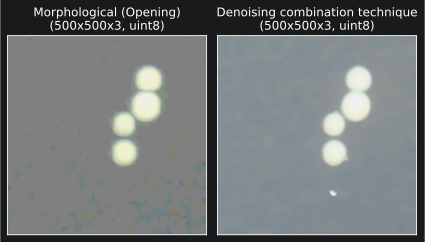

In [9]:
# Comparison Morphological opening & function blur()
# Definition structuring element
se = cv.getStructuringElement(cv.MORPH_RECT, (7, 7)) # 7, 7 works, 5,5 & 10,10 does not
morph_open = cv.morphologyEx(imgs_all_color[7].copy(), cv.MORPH_OPEN, se, iterations=2)

# Show comparison
tools.show_image_pair(morph_open, imgs_all_blurred[7], title1="Morphological (Opening)", title2="Denoising combination technique")

### **Our Final Denoising Method**
* Morphological opening combined with Non-local denoising and Median blur.
* Below we illustrate how the combination affects the output (only morphological opening in comparison to our final denoising technique).
* Additionally, we show how the edge representation changes in the process. If we use only the morphological opening technique, the colonies in the mask would appear angular.

In [10]:
def denoise_img(img, morphological_opening=True, iterations=2, blurring=True):
    """
    Preprocess image with morphological opening and optional denoising/blurring.

    :param img: input image out of imgs_all_color
    :param morphological_opening: apply morphological opening (default: True)
    :param iterations: number of iterations for morphological opening (default: 2)
    :param blurring: apply Non-Local denoising + median blur (default: True)
    :return: denoised image
    """
    # Morphological opening
    if morphological_opening:
        se = cv.getStructuringElement(cv.MORPH_RECT, (7, 7))
        img = cv.morphologyEx(img, cv.MORPH_OPEN, se, iterations=iterations)

    # Denoising and blurring
    if blurring:
        img = cv.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)
        img = cv.medianBlur(img, 9)

    return img

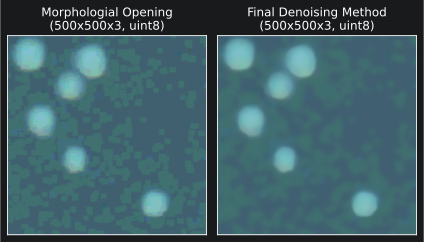

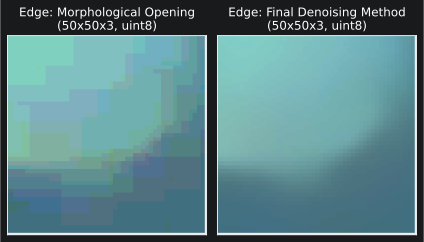

In [11]:
## For demonstration purposes, denoise_img with blurring = False
imgs_all_opened = [denoise_img(i.copy(), morphological_opening=True, iterations=2, blurring=False) for i in imgs_all_color]

## Illustration of adapted pre-processing: morphological opening in combination with Non-Local denoising.
# Image after morphological opening
opened_only = imgs_all_opened[10].copy()

# Additionally applied non-local denoising and median blur to smooth
opened_smoothed = blur(opened_only)

# Show images
tools.show_image_pair(opened_only, opened_smoothed, title1="Morphologial Opening", title2="Final Denoising Method")

## Edge representation
edge_opened = imgs_all_opened[8].copy()
edge_open_smooth = cv.fastNlMeansDenoisingColored(edge_opened, None, 10, 10, 7, 21)

# Show edges
tools.show_image_pair(edge_opened[210:260, 200:250], edge_open_smooth[210:260, 200:250], title1="Edge: Morphological Opening", title2="Edge: Final Denoising Method")

### **Final Denoising in a batch**

In [12]:
# Batch processing using the final denoising methode denois_img()
imgs_all_denoised = [denoise_img(i) for i in imgs_all_color]

---

<a id='sec_manual_segmentation'></a>

## **Manual segmentation**

### **Export imgs_all_color for manual segmentation**
We exported the dataset to use it for manual segmentation.

*Note: It is marked as "Disabled" as this is not necessary for general usage.*

In [13]:
# # Export imgs_all_color for manual segmentation
# titles = ["red_1", "red_2", "red_3", "red_4", "white_1", "white_2", "white_3", "white_4", "green_1", "green_2", "green_3", "green_4"]
#
# def saving_img(imgs):
#     for i, img in enumerate(imgs):
#         img_pil = Image.fromarray(img)
#         img_pil.save(f"{titles[i]}.png")
#
# saving_img(imgs_all_color)

### **Using GIMP v3.2.4 for manual segmentation**

GIMP is a free, open-source image editor for photo manipulation, retouching, and digital art. It supports layers, filters, and various image formats, and can be scripted for batch processing workflows.

For our project, we did not use a batch processing but made the manual segmentation individual for every image: A very repetitive process with slight variations depending on the input image.

**Overview: Manual Segmentation Steps**
* Open image
* Layers -> New Layer
* Select original image in layers panel
* Tools -> Selection Tools -> By Color Selection (drag over colonies to assign colors)
* Select -> Sharpen (if necessary followed by shrink or grow)
* Tools -> Select Tools -> Retangle Select -> Substract unwanted patterns
* Select new layer in layer panel
* Tools -> Paint Tools -> Bucket Fill (Fill colonies white)
* Select -> Invert
* Tools -> Paint Tools -> Bucket Fill (Fill background black)
* File -> Export (the mask) as .png

### **Sorting GIMP masks**
We need to sort the GIMP masks so they match the order of image representeation:
* Sort according to the name -> Red, White, Green
* And to their numbers -> 1 to 4

In [13]:
# Define image folder
image_folder = "gimp_masks"

# Get all image files
image_files = [f for f in os.listdir(image_folder)
               if f.lower().endswith(('.png'))]

# Prepare key for sorting
def sort_key(filename):
    """
    Extract color and number from filename for sorting.
    Returns a tuple (color_priority, number) for proper ordering.
    """
    color_priority = {'red': 0, 'white': 1, 'green': 2}

    # Extract color (case-insensitive)
    color = None
    for col in color_priority.keys():
        if col in filename.lower():
            color = color_priority[col]
            break

    # Extract number (finds first sequence of digits)
    number_match = re.search(r'\d+', filename)
    number = int(number_match.group()) if number_match else 0

    return (color, number)

# Sort the files
image_files.sort(key=sort_key)

# Load images as grayscales into a list
gimp_images_sorted = []
for filename in image_files:
    filepath = os.path.join(image_folder, filename)
    image = cv.imread(filepath, cv.IMREAD_GRAYSCALE)
    gimp_images_sorted.append(image)

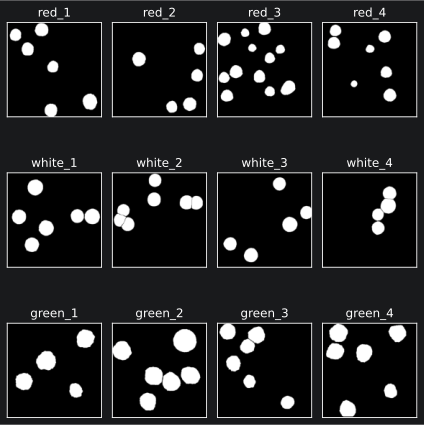

In [14]:
# Show manual GIMP masks
tools.show_image_grid(gimp_images_sorted, suppress_info=True, ncols=4, figsize=(6, 7), titles= titles_all_color)

---

<a id='sec_automated_segmentation'></a>

## **Automated Segmentation**

The segment() function uses K-means clustering + connected components labeling to identify individual colonies.
Watershed would have been a possibility as well, but it seemed the method had troubles with our dataset as it did not manage to clearly segment our colonies. We tried as well a thresholding technique based on the color variation of our petri dishes. But we then realized that it was much easier to use k-means, because in the end what we want from every image is a binary classification (K=2) of background and colony.

Process:
1. K-means Clustering (K=2)
   - Groups pixels into 2 clusters based on RGB color similarity
   - Separates colonies from background
2. Background Detection
   - Identifies which cluster is background (the larger region)
   - Ensures colonies are correctly labeled regardless of k-means assignment order
3. Binary Mask Creation
   - Creates a 0/255 mask: white=colonies, black=background
4. Connected Components Labeling
   - Identifies individual colonies as separate connected regions
   - Each colony gets a unique label (1, 2, 3, ...)
   - Connectivity=8 means pixels touching horizontally, vertically, OR diagonally count as connected

Returns:
- binary_mask: Final segmentation mask (0=background, 255=colonies)
- colony_labels: Array of unique colony IDs
- connected_labels: Label map showing which colony each pixel belongs to

In [15]:
def segment(img, K=2, connectivity=8):
    """
    Segment colonies in a petri dish image using K-means clustering and connected components.

    Process:
    1. Use K-means to separate colonies from background
    2. Automatically determine which cluster is background (larger region)
    3. Apply connected components labeling to identify individual colonies

    :param img: input image (morphological opening should be applied beforehand)
    :param K: number of K-means clusters (default: 2 for background + colonies)
    :param connectivity: connectivity for connected components (4 or 8, default: 4)
    :return: binary_mask (0=background, 255=colonies), colony_labels (unique label per colony),
             connected_labels (label map showing which colony each pixel belongs to)
    """
    # K-means clustering
    data = img.reshape(-1, 3).astype(np.float32)
    criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 0.1)
    _, kmeans_labels, centers = cv.kmeans(data, K=K, bestLabels=None,
                                          criteria=criteria, attempts=10,
                                          flags=cv.KMEANS_PP_CENTERS)

    # Reshape k-means labels back to image dimensions
    kmeans_labels = kmeans_labels.reshape(img.shape[:2])

    # Determine which label is background (larger region typically)
    label_0_size = np.sum(kmeans_labels == 0)
    label_1_size = np.sum(kmeans_labels == 1)
    colonies_label = 1 if label_0_size > label_1_size else 0

    # Create binary mask of colonies
    colony_mask = (kmeans_labels == colonies_label).astype(np.uint8) * 255

    # Find connected components (individual colonies)
    _, connected_labels = cv.connectedComponents(colony_mask, connectivity=connectivity)

    # Create binary output mask
    binary_mask = (connected_labels > 0).astype(np.uint8) * 255

    # Get unique colony labels (excluding background label 0)
    colony_labels = np.unique(connected_labels)[1:]

    return binary_mask, colony_labels, connected_labels

# Creating a list to store returned values from segment()
imgs_all_segmented = [segment(i) for i in imgs_all_denoised]

# Separating returned outputs
imgs_segmented = [result[0] for result in imgs_all_segmented]
counted_colonies = [result[1] for result in imgs_all_segmented]
all_connected_labels = [result[2] for result in imgs_all_segmented]

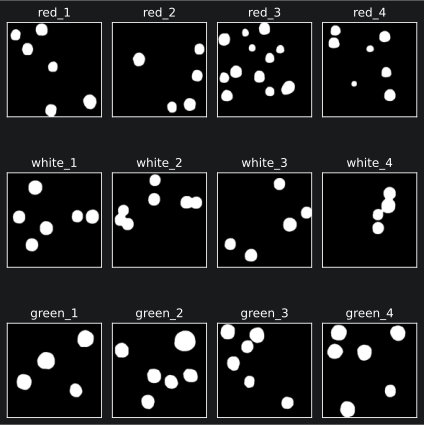

In [16]:
# Show automated masks
tools.show_image_grid(imgs_segmented, suppress_info=True, ncols=4, figsize=(6, 7), titles= titles_all_color)

---

<a id='sec_evaluation'></a>

## **Evaluation**
For evaluation, we use the manually generated segmentation mask as the ground truth and compare it with the segmentation predicted by the automated method.

* We used two evaluation metrics.
    * Ability to count correctly -> number of colonies seen on the automated segmentation masks
    * Dice Score -> similarity between ground truth mask (GIMP) and automated masks

### **Result Counting**

* Here we show the results returned by the automated segmentation

In [17]:
# print counted colonies / image by segment()
for title, count in zip(titles_all_color, counted_colonies):
    print(f"{title}: {len(count)} colonies")

red_1: 6 colonies
red_2: 5 colonies
red_3: 12 colonies
red_4: 7 colonies
white_1: 6 colonies
white_2: 4 colonies
white_3: 5 colonies
white_4: 2 colonies
green_1: 4 colonies
green_2: 6 colonies
green_3: 6 colonies
green_4: 6 colonies


The table below illustrates how the predicted amount is off compared to the true amount of colonies.
See how only the images with touching colonies were not segmented correctly and therefore yield a wrong result.

| Image   | Touching Colonies | True Amount Colonies | Predicted Amount Colonies | Off-Set |
|---------|:-----------------:|:--------------------:|:-------------------------:|:-------:|
| red_1   |       False       |          6           |             6             |    0    |
| red_2   |       False       |          5           |             5             |    0    |
| red_3   |       False       |          12          |            12             |    0    |
| red_4   |       False       |          7           |             7             |    0    |
| white_1 |       False       |          6           |             6             |    0    |
| white_2 |     **True**      |        **7**         |           **4**           |  **3**  |
| white_3 |       False       |          5           |             5             |    0    |
| white_4 |     **True**      |        **4**         |           **2**           |  **2**  |
| green_1 |       False       |          4           |             4             |    0    |
| green_2 |       False       |          6           |             6             |    0    |
| green_3 |       False       |          6           |             6             |    0    |
| green_4 |       False       |          6           |             6             |    0    |

### **Result Dice Score**

**Analyzing the masks using dice scoring and overlay**

The evaluate() function compares automated segmentation masks against ground truth masks
by computing similarity metrics and creating visual overlays.

Process:
1. Binary Conversion
   - Converts both ground truth and automated masks to binary (0/255) using threshold
   - Default threshold=127 treats pixels >127 as foreground, <=127 as background
2. Dice Coefficient Calculation
   - Measures overlap similarity between ground truth and automated masks
   - Formula: 2 * (intersection) / (sum of both masks)
   - Range: 0 (no overlap) to 1 (perfect match)
3. Overlay Visualization
   - Creates color-coded overlay on original image:
     * Red = ground truth mask
     * Green = automated mask
     * Yellow = overlap (where both agree)
   - Uses alpha=0.5 for transparency
4. Batch Processing
   - Processes all 12 images in parallel using zip()
   - Returns lists of overlays and Dice scores for comparison

Returns:
- overlay_results: List of images with ground truth (green) + automated (red) overlays
- dice_scores: List of Dice coefficients (0-1) for each image pair

In [18]:
def evaluate(orig_imgs, ground_truth_imgs, automated_masks, threshold=127, alpha=0.5, return_dice=True):
    """
    Analyze masks by computing Dice coefficient and creating overlay visualization for multiple images.

    Args:
        orig_imgs: List of original images (each shape: (H, W, 3))
        ground_truth_imgs: List of ground truth masks (each shape: (H, W))
        automated_masks: List of automated masks (each shape: (H, W))
        threshold: Binary threshold (default 127)
        alpha: Blend transparency for overlay (default 0.5)
        return_dice: If True, also return Dice coefficients (default True)

    Returns:
        If return_dice=True: (list of overlay images, list of dice scores)
        If return_dice=False: list of overlay images
    """
    overlay_results = []
    dice_scores = [] if return_dice else None

    for orig_img, gt_img, auto_img in zip(orig_imgs, ground_truth_imgs, automated_masks):
        # Convert masks to binary
        gt_binary = (gt_img > threshold).astype(bool)
        auto_binary = (auto_img > threshold).astype(bool)

        # Compute Dice coefficient if requested
        if return_dice:
            intersection = gt_binary & auto_binary
            dice_score = 2 * np.sum(intersection) / (np.sum(gt_binary) + np.sum(auto_binary))
            dice_scores.append(dice_score)

        # Convert to uint8 for overlay
        gt_binary_uint8 = gt_binary.astype(np.uint8) * 255
        auto_binary_uint8 = auto_binary.astype(np.uint8) * 255

        # Create color overlays
        red_overlay = np.zeros_like(orig_img)
        red_overlay[:, :, 0] = gt_binary_uint8

        green_overlay = np.zeros_like(orig_img)
        green_overlay[:, :, 1] = auto_binary_uint8

        # Blend with original image
        result = cv.addWeighted(orig_img, 1, red_overlay, alpha, 0)
        result = cv.addWeighted(result, 1, green_overlay, alpha, 0)

        overlay_results.append(result)

    return (overlay_results, dice_scores) if return_dice else overlay_results


# Overlay and Dice score
overlay, dice = evaluate(imgs_all_color, gimp_images_sorted, imgs_segmented)

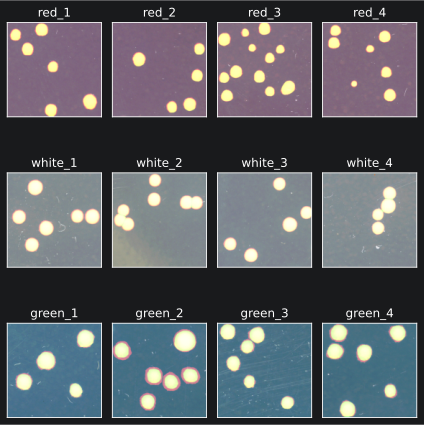

In [19]:
# Show overlay images (original, ground truth mask, automated mask)
tools.show_image_grid(overlay, suppress_info=True, ncols=4, figsize=(6, 7), titles=titles_all_color)

In [20]:
# print Dice Score per image
for title, dice_score in zip(titles_all_color, dice):
    print(f"Dice score {title}: {round(dice_score, 3)}")

Dice score red_1: 0.903
Dice score red_2: 0.924
Dice score red_3: 0.931
Dice score red_4: 0.898
Dice score white_1: 0.889
Dice score white_2: 0.899
Dice score white_3: 0.905
Dice score white_4: 0.936
Dice score green_1: 0.912
Dice score green_2: 0.788
Dice score green_3: 0.908
Dice score green_4: 0.886


The table below displays the dice scores calculated comparing similarity between the automated mask and the ground truth mask.
The Dice Scores are all in the range of 0.9 which represents a very good agreement of the two sets. This is coherent with the visual overlap which shows that the majority of the colonies are displayed yellow (agreeing area of ground truth and automated mask). We barely see red areas on the edges which are displaying the ground truth only, indicating that the manual segementation masks are covering larger areas compared to the automated mask. This is very prominent in *green_2*, where the ground truth masks are considerably larger than the automated mask resulting in a Dice Score of 0.788 (still a good agreement). This illustrates that the manual segmentation is rather inconsistent over all images and the automated approach is more standardized. The colonies are compressed during the preprocessing and result in a smaller area in the mask, an expected artifact.

| Image       | Touching Colonies | Dice Score |
|-------------|:-----------------:|:----------:|
| red_1       |       False       |   0.903    |
| red_2       |       False       |   0.924    |
| red_3       |       False       |   0.931    |
| red_4       |       False       |   0.898    |
| white_1     |       False       |   0.889    |
| white_2     |       True        |   0.899    |
| white_3     |       False       |   0.905    |
| white_4     |       True        |   0.936    |
| green_1     |       False       |   0.912    |
| **green_2** |     **False**     | **0.788**  |
| green_3     |       False       |   0.908    |
| green_4     |       False       |   0.886    |

In [21]:
# Statistics
mean = round(np.mean(dice), 3)
std_dev = round(np.std(dice), 3)

print(f"Mean dice score: {mean}")
print(f"Standard deviation of dice scores: {std_dev}")

Mean dice score: 0.898
Standard deviation of dice scores: 0.037


With a mean (SD) Dice Score of 0.90 (0.04), the overlap between the predicted and ground truth masks was high. The low SD indicates stable and consistent segmentation performance across the dataset. However, these results have to be interpreted with caution, as the dataset was small and homogeneous.

---------
## **An attempt to separate touching colonies using thresholding**
* We choose deliberatly 2 out of 12 images, containing touching colonies.
* Below is our approach to segment these colonies using intensity-based thresholding.
* Our strategy was to make use of the color differences within each colony.
    * While the innermost regions exhibit maximum intensity (brightest), intensity decreases progressively toward the colony edges.
* Trying to exploit this feature, we visualized the pixels of interest (innermost, touching edges).
    * We used the morphological opened version of *white_4*

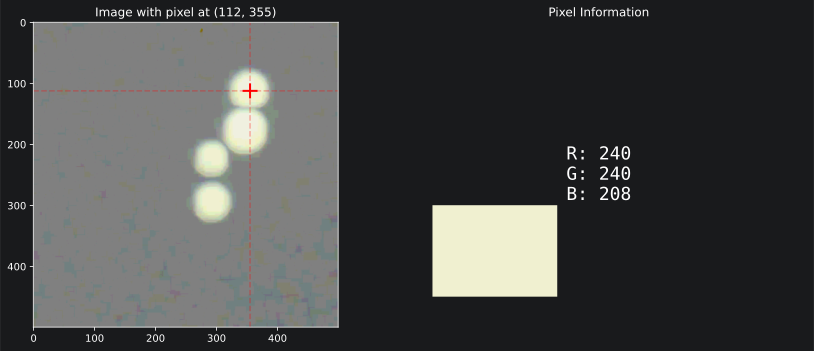

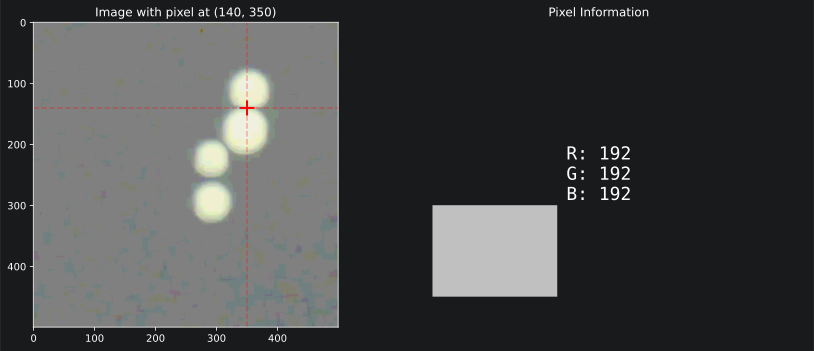

In [22]:
# Load image white_4
img_white_4 = imgs_all_opened[7].copy()

def visualize_pixel(img, x, y):
    """
    Visualize a pixel at position (x, y) and display its value.

    Args:
        img: Image array
        x: Row coordinate (vertical position)
        y: Column coordinate (horizontal position)
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Display image with marked pixel
    axes[0].imshow(img)
    axes[0].plot(y, x, 'r+', markersize=15, markeredgewidth=2)  # Note: imshow uses (y, x) for plotting
    axes[0].set_title(f"Image with pixel at ({x}, {y})")

    # Add crosshair lines to make it more visible
    axes[0].axhline(y=x, color='r', alpha=0.3, linestyle='--')
    axes[0].axvline(x=y, color='r', alpha=0.3, linestyle='--')

    # Display pixel value(s)
    pixel_value = img[x, y]

    if len(img.shape) == 2:  # Grayscale
        axes[1].text(0.5, 0.5, f"Pixel Value: {pixel_value}",
                    fontsize=20, ha='center', va='center',
                    transform=axes[1].transAxes)
    else:  # Color image
        r, g, b = pixel_value[0], pixel_value[1], pixel_value[2]
        text = f"R: {r}\nG: {g}\nB: {b}"
        axes[1].text(0.5, 0.5, text,
                    fontsize=18, ha='center', va='center',
                    transform=axes[1].transAxes, family='monospace')

        # Show a preview of the color
        axes[1].add_patch(plt.Rectangle((0.1, 0.1), 0.3, 0.3,
                                       facecolor=np.array([r, g, b])/255,
                                       transform=axes[1].transAxes))

    axes[1].axis("off")
    axes[1].set_title("Pixel Information")

    plt.tight_layout()
    plt.show()

# Usage
visualize_pixel(img_white_4, 112, 355)
visualize_pixel(img_white_4, 140, 350)

### **Using retrieved color information as input for thresholding**
* The values appear to be quite distinct to each other. Which is necessary for the process.
* Using the values identified we were able to apply a segmentation by color.

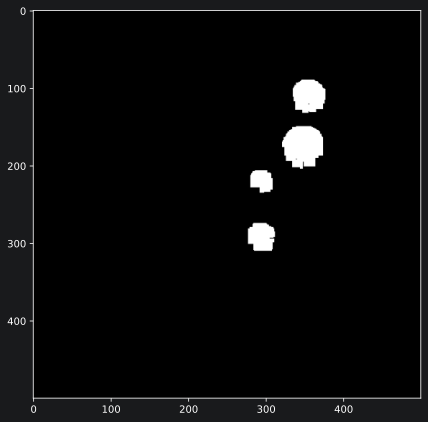

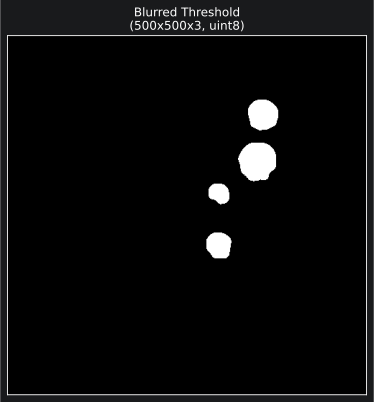

In [23]:
def segment_by_color(img, target_rgb, tolerance=5, channel_weights=None):
    """
    Segment image based on target RGB color with tolerance.

    Args:
        img: RGB image array
        target_rgb: Target color as [R, G, B]
        tolerance: How much variance allowed per channel (default: 5)
        channel_weights: Optional weights for each channel [R, G, B]
                        Use this to emphasize certain channels (e.g., [1, 1, 3] for blue)

    Returns:
        Binary mask (True where color matches)
    """
    # Extract channels
    r = img[:, :, 0]
    g = img[:, :, 1]
    b = img[:, :, 2]

    target_r, target_g, target_b = target_rgb

    # Creates masks for each channel
    r_match = np.abs(r - target_r) <= tolerance
    g_match = np.abs(g - target_g) <= tolerance
    b_match = np.abs(b - target_b) <= tolerance

    # All channels must match
    mask = r_match & g_match & b_match

    return mask

# Threshold for the object of interest (innermost part of colony) + some tolerance to increase amount of retrieved pixels.
object_mask = segment_by_color(img_white_4, target_rgb=[240, 240, 208], tolerance=20)

# Create segmented image (keep only the object)
segmented = img_white_4.copy()
segmented[~object_mask] = 0  # Set everything else to black
segmented[object_mask] = 255

plt.figure(figsize=(7, 7))
plt.imshow(segmented)
plt.show()

blurred_threshold = cv.medianBlur(segmented, 9)

tools.show_image(blurred_threshold, title="Blurred Threshold")

### **Issues and Outlook**
* The results were quite promising: As shown in the images, we were able to separate the colonies and we got 4 distinct entities.
* Unfortunately, this technique is not feasible as an automated approach yet because:
    * we would need to implement an automated identification of the brightest pixels of each image.
    * But even so, success is not guaranteed as the example below demonstrates.

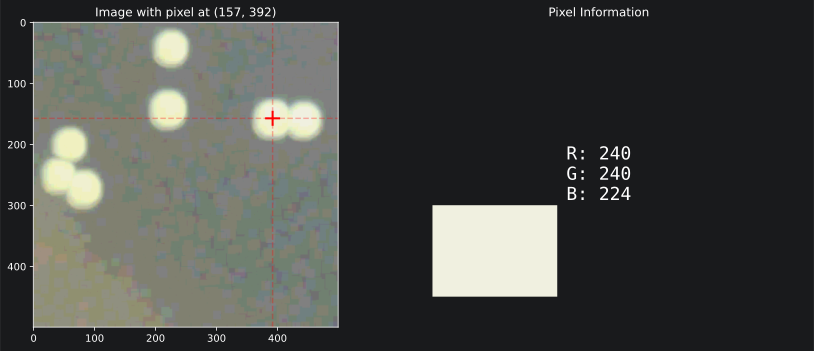

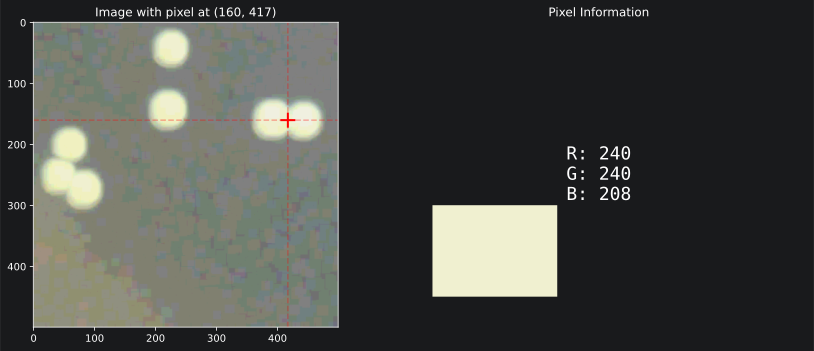

In [24]:
img_white_2 = imgs_all_opened[5].copy()

# Usage
visualize_pixel(img_white_2, 157, 392)
visualize_pixel(img_white_2, 160, 417)

### **Variation in intensity across colonies**
* Here we see that the intensity varies between spatial locations.
* Therefore, selecting the highest intensity does not guarentee a succesfull segmentation.
* We lost one colony and seperation is still not optimal.

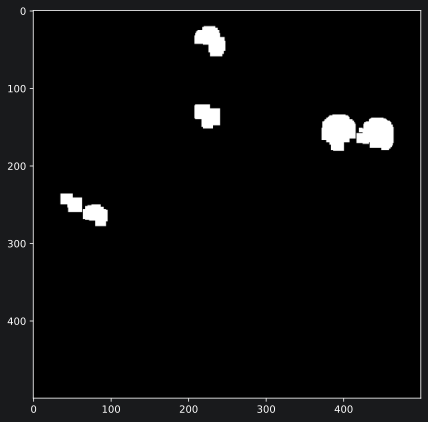

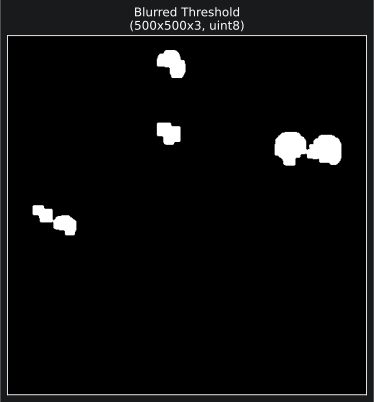

In [25]:
# Threshold for the object of interest (innermost part of colony) + some tolerance to increase amount of retrieved pixels.
object_mask = segment_by_color(img_white_2, target_rgb=[240, 240, 208], tolerance=20) # Edge color used instead of inner part, as the other way around it dit not work at all.

# Create segmented image (keep only the object)
segmented = img_white_2.copy()
segmented[~object_mask] = 0  # Set everything else to black
segmented[object_mask] = 255

plt.figure(figsize=(7, 7))
plt.imshow(segmented)
plt.show()

blurred_threshold = cv.medianBlur(segmented, 3)

tools.show_image(blurred_threshold, title="Blurred Threshold")

### **Conclusion**
* This method would need more fine tuning before being suitable for an automated approach.
* Although the method was not a perfect success, this was a fun side task to work on.

---

<a id='sec_discussion'></a>

## **Discussion**

This project was a fun task to work on. Especially since we were able to use our self-made dataset. It gave us the impression to work on a "real-world" task.

* **Input data**: The original input image which was a scan of several plates had to be cropped manually to obtain individual plates. For a complete automation of all steps, we would need to predefine plate positions on the scanner in order to facilitate the extraction. Additionally, a different scanner should be considered, as the current one is very slow when using the higest possible resolution.

* **Quantization**: We only experimented with 4 and 6-bit quantization so far. Lower bit depths could be explored, although at some point the color variation within a colony would cluster all colors togheter. In that case, seperation of touching colonies would most probably not be feasable anymore. For now, 4-bit was a nice sweet spot.

* **Manual snippet selection**: Ideally, we would be able to count all colonies on the whole plate, not only on snippets. This was a trade-off we had to anticipate in order to be able to finish this project in time. With additional time, we would implement a method to separate the whole petri dish image into equal snippets, slightly overlapping each other. Colony centers could then be detected and assigned to the snippet containing them, allowing for aggregation across all snippets to obtain the total colony count per plate. Several challenges would need to be addressed, including background regions outside the petri dish, detection of the petri dish edge (which was a huge challenge before we decided to leave this feature out), as well as labels written on the petri dish surface.

* **Denoising**: Was one of the most challenging parts. We went a lot back and forth trying to decide what makes sense to use, especially when conidering what suits best for subsequent steps. Single blurring techniques didn't work out as we illustrated showing only the Non-Local Denoising. Only in combination with the median blur we were able to get rid of all noise in the image. So we came up with the combinations. Often we encountered that a particular solution was not beneficial at all in the end and we had to go back. This was often the case when trying to separate touching colonies. We tried to show this by first introducing the denoising combination technique, only to then realize that it is not working out and adapting the process to use morphological opening techniques in addition.

* **Manual segmentation**: This step took a lot longer than anticipated, as we first had to figure out an appropriate tool and workflow. We were not previously familiar with GIMP, and proceeded with it as we were not familiar with any alternative tools either. Establishing a consistent segmentation routine was somewhat frustrating, but we managed to complete it. What we realized is that the manual selection produces larger areas considered a colony comparing to our automated approach. Especially in the green plates the colony edges were hard to detect even by eye. This is shown with the "worst" scores when comparing colors.

* **Automated segmentation**: K-means clustering proved to be very strong with this segmentation task from the beginning. We tried out other techniques as well, however, the watershed method did not produce satisfactory results, and the AI-based background isolation approach was not even running. As expected initially, our automated segmentation function was not able to separate touching colonies. We tried to adapt the preprocessing a lot in order to make it work but nothing really happend to be successful. The most promising approach was to experiment more with morphological techniques, especially erosion, but we were not successful.

* **Results "Counting"**: The results obtained from the automated segmentation were perfect in images without touching colonies. We yielded the exact number of colonies for each image which had its colonies separated. Proving that our automated approach using k-means works. However, in reality touching colonies occure very often. For our project we choose regions without touching colonies on purpose. So our approach is nice, but not suitable for "real" datasets.

* **Results "Dice Score"**: Our Dice Scores are almost all around 0.9 which can be interpreted as a very good overlap of ground truth mask and the automated mask. As already mentioned, the ground truth masks used to be larger, which can be seen in the overlapped images. Only red edged are partially present (ground truth), otherwise the colonies appear yellow throughout indicating the overlapping areas of both masks.

* **Our attempt to segment touching colonies**: We are quite happy with the results obtained by our attempt, although it is not perfect. As mentioned, this method is not suited for an automated approch yet. It involved a lot of try & error and for a long time it did not work at all. The results we presented here are the best performance we were able to achieve. Out of two images containing touching colonies, one could be successfully processed to obtain separated colonies. Initially only 2 colonies were detected, whereas the improved approach was able to distinguish 4 distinct entities.

---

<a id='sec_references'></a>

## **References**

* Dataset was made in the laboratories of the Institute of Medical Virology at the University of Zurich. We thank Prof. Alexandra Trkola for her help in this task.

* A lot of the code in this project is based on the ones provided by the jupyter notebook for CO4.
* Denoising: https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html, https://docs.opencv.org/4.x/d5/d69/tutorial_py_non_local_means.html
* GIMP: https://www.gimp.org/downloads/
* Connected Components: https://en.wikipedia.org/wiki/Connected-component_labeling
* We used generative AI tools (ChatGPT, Claude.ai) to help with the coding tasks. We especially used those tools to compress multiple functions into one, in order to have a better overview. Debugging was a vital part as well. Often the format of the images was not right, preventing the code to run. AI tools helped to identify those issues and as well help to locate the part of the code where the issue was to be fixed. We tried to avoid using code which was only generated by AI.